# Gravitational Wave progenitors

## A guide to binary stars and stellar interactions

In [1]:
# Import external packages, and supply settings used throughout the tutorial - you can ignore this cell
import numpy as np
import h5py as h5
from scipy.optimize import fsolve
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import AppLayout, FloatSlider, Play, IntSlider, widgets, HBox, VBox, interact, interactive
from IPython.display import YouTubeVideo
from scripts.BHSummerSchoolUtils import printCompasDetails, get_data, make_interactive_widget

%matplotlib widget

### As we saw on Wednesday, stellar-mass black holes come from massive stars. To understand black hole formation, we need to understand stellar evolution.

#### However, the story gets more complicated. Most black holes that we can observe are not isolated: they are in binary star systems and have experienced (or are currently experiencing) binary interactions.

 <img src="data/images/binary_star.jpg" alt="Drawing" style="width: 600px;"/>

### Two major breakthroughs in the last 15 years have really changed our understanding and appreciation of binaries

#### - 1st: In 2012, a team of researchers, led by a KU Leuven professor, carefully measured the massive stars in our Galaxy, and found that ~70% have a close binary companion. 

#### - Later research found that as you increase the mass of the biggest star, you increase the likelihood that it has even more companions.

 <img src="data/images/sana12.png" alt="Drawing" style="width: 600px;"/>
[Sana et al. 2012]

 <img src="data/images/mds17.png" alt="Drawing" style="width: 600px;"/>
[Moe & Di Stefano 2017]

### - 2nd: In 2015, the LIGO collaboration made the groundbreaking discovery of Gravitational Waves from the merger of two black holes.

 <img src="data/images/ligo_merger.png" alt="Drawing" style="width: 600px;"/>
[Abbott et al. 2016]

### The takeaway: You can't study black holes without accouting for _binarity_. 

### So what is a binary star?

 <img src="data/images/binary_star_basic.png" alt="Drawing" style="width: 400px;"/>
Binaries at their simplest can be described by 2 masses, a separation (or period), and eccentricity.

#### Historically, we’ve known about binary stars for many centuries. _Visual binaries_ are any two stars that appear very close on the sky. Of course, without knowledge of the distance to the stars, we don’t know if they are in a _true binary_, or just an _apparent binary_. 

 <img src="data/images/apparent_binary.png" alt="Drawing" style="width: 600px;"/>
 Model of an apparent binary [Pols (2018)]

#### Early astronomers used statistical arguments to show there must be _some_ true binaries, but they couldn’t identify them individually.

#### If at least one of the stars is sufficiently close, and you have a good enough telescope, you should be able to distinguish any apparent binaries based on their _parallax_. 

Challenge problem: find the conversion factor between an Astronomical Unit (AU) and a parsec (pc). How does this depend on the distance between the Earth and the Sun?

### In the late 1600s, telescopes improved to the point that astronomers could detect periodic dips in brightness, which they attributed to _eclipsing binaries_. These are systems that appear as a single point on the sky - they cannot be resolved individually - but the orbit is very nearly edge on. 

#### When the stars approach _conjuction_, one of the stars eclipses the other, and the overall brightness goes down. This happens in a predictable, periodic way, and is thus observationally distinct from, e.g., random variations on the surface of the stars, or a cloud of dust passing between the system and the observer. 

 <img src="data/images/eclipsing_binary.jpg" alt="Drawing" style="width: 600px;"/>

#### Here is a [binary eclipse simulator](https://ccnmtl.github.io/astro-simulations/eclipsing-binary-simulator/). Play with the parameters of the star and see how they affect the light curve. 

Challenge: can you find the correct parameters to match the lightcurves in any of Presets 18-24?

### We can also identify non-eclipsing binaries using _spectroscopy_. Spectroscopy is the science of splitting the light from a distant star into its constituent wavelengths. 

#### If the resolution is good enough, you can identify characteristic _spectral lines_ associated to certain atoms or molecules. This can tell you about the composition of a star (or galaxy, or gas cloud, etc.), but the positions of these lines are also well known from theory. 

#### For example, the famous Hydrogen-alpha (or H-alpha) line has a rest-frame wavelength of 656.46 nm. Due to Doppler shifting, any relative motion between a source frame and the observer frame leads to shifts in the observed wavelength which are exclusively a function of the relative velocity. Objects moving toward us are “blue-shifted” toward shorter wavelengths, while objects moving away from us are “red-shifted” to longer wavelengths. 

#### This is widely used for determining the redshift to distant galaxies, but more locally we can determine orbits of binaries if we see periodic red- and blue-shifting of these spectral lines.

[<img src="data/images/spectral_lines.gif" alt="Drawing" style="width: 500px;"/>](https://www.astronomy.ohio-state.edu/pogge.1/Ast162/Movies/spanim.gif)

### Once we have identified a binary star, one of the easiest parameters to measure is the orbital period (at least for relatively short periods). 

#### ❓ Q: What is the relationship between orbital period and separation? How can we simplify this to enable easier mental math?

### On the theoretical side, we can consider how the pull of gravity changes in a binary system. Very close to either star, the gravitational potential is very nearly spherical - as it is for just a single star. But as you move away from the star, the influence of gravity from the other star becomes more relevant. 

#### This is well-understood mathematically, so we can plot curves of constant gravitational potential around the binary. We can also identify _stable points_ within these potentials. 

#### These are points where the potential is 0, so a small mass that is sitting at these points will not move. The French mathematician Lagrange was the first to do this calculation, so we refer to these as the 5 Lagrangian points. These are particularly useful for placing telescopes, because they will naturally stay put! In fact the James Webb Space Telescope is positioned at the L2 point for this reason, and the future LISA gravitational wave telescope array will live at the L1 point. 

<img src="data/images/roche_lobe.png" alt="Drawing" style="width: 500px;"/>

In [5]:
#### Plot the equipotential lines around a binary, highlighting the Lagrangian points and surfaces

# Constants
G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2
M_sun = 1.989e30 # Mass of the sun in kg
AU = 1.496e11  # Approximately 1 AU

# Function to calculate gravitational potential at a point (x, y)
def gravitational_potential(x, y, m1, m2, a):
    # Positions of the two stars
    x1, y1 = -a * m2 / (m1 + m2), 0
    x2, y2 = a * m1 / (m1 + m2), 0

    # Distances from the point to each star
    r1 = np.sqrt((x - x1)**2 + (y - y1)**2)
    r2 = np.sqrt((x - x2)**2 + (y - y2)**2)

    # Gravitational potential at the point (x, y)
    omega_sqrd = G*(m1 + m2) / a**3
    phi = -G * (m1 / r1 + m2 / r2) - 0.5*omega_sqrd*(x**2 + y**2)

    return phi

def get_Lagrange_123(m1, m2):
    s0_s1 = [[-1, -1],
             [-1, 1],
             [1, 1]]
    
    alpha = m2/(m1+m2)
    allroots = []
    for (s0, s1) in s0_s1:
        poly = [
            1,
            3 - alpha,
            3 - 2*alpha,
            1 - s1 - alpha*(1 + s0 - s1),
            -2*alpha*s0,
            -alpha*s0
        ]
        roots = np.roots(poly)
        realroot = roots[np.isreal(roots)].real
        allroots.append(realroot)
    
    L1 = allroots[1]
    if m2/m1 > 1:
        L2 = allroots[0]
        L3 = allroots[2]
    else:
        L2 = allroots[2]
        L3 = allroots[0]
    return np.array([L1, L2, L3]).flatten()

def get_positions_rel_to_CoM(m1, m2):
    L1, L2, L3 = get_Lagrange_123(m1, m2)
    posD = -1
    posA = 0
    beta = m1/(m1+m2)
    xCom = -beta
    l1l2l3pDpA_relToCom = np.array([L1, L2, L3, posD, posA]) - xCom
    return l1l2l3pDpA_relToCom

# Function to calculate and plot equipotential surfaces
def plot_equipotential_surfaces(fig, ax, m1, m2, a, scale_factor=3, zoom=1, xcntr=0, num_contours=15, contour_min=0.1, contour_max=2):
    # Define the grid
    x_min, x_max = -scale_factor * a, scale_factor * a
    y_min, y_max = x_min, x_max
    n_points = 500

    x = np.linspace(x_min, x_max, n_points)
    y = np.linspace(y_min, y_max, n_points)
    X, Y = np.meshgrid(x, y)

    # Calculate the potential at each point on the grid
    Z = gravitational_potential(X, Y, m1, m2, a)

    # Find the Lagrangian points
    L1, L2, L3, x1, x2 =  a*get_positions_rel_to_CoM(m1, m2)

    # Calculate potential at Lagrangian points
    phi_L1 = gravitational_potential(L1, 0, m1, m2, a)
    phi_L2 = gravitational_potential(L2, 0, m1, m2, a)
    phi_L3 = gravitational_potential(L3, 0, m1, m2, a)
    if phi_L2 > phi_L3:
        phi_tmp = phi_L2
        phi_L2 = phi_L3
        phi_L3 = phi_tmp
        Ltmp = L2
        L2 = L3
        L3 = Ltmp

    # Plot the equipotential surfaces
    contour_levels = phi_L1*np.linspace(contour_min, contour_max, num_contours, endpoint=True)[::-1]
    ax.contour(X, Y, Z, levels=contour_levels, colors='black', linestyles='-', alpha=0.3)

    # Highlight the equipotential lines passing through Lagrangian points
    ax.contour(X, Y, Z, levels=[ phi_L1, phi_L2, phi_L3 ], colors=['red', 'blue', 'green'], linestyles='--', linewidths=3)

    # Plot the positions of the stars and the Lagrangian points
    ax.scatter([-a * m2 / (m1 + m2), a * m1 / (m1 + m2)], [0, 0], color='white', s=100, edgecolor='black', label='Stars')
    ax.scatter([L1], [0], color='red',   s=300, marker='*', label='L1')
    ax.scatter([L2], [0], color='blue',  s=300, marker='*', label='L2')
    ax.scatter([L3], [0], color='green', s=300, marker='*', label='L3')
    ax.scatter([x1+a/2], [a*np.sqrt(3)/2], color='orange', s=300, marker='*', label='L4')
    ax.scatter([x1+a/2], [-a*np.sqrt(3)/2], color='orange', s=300, marker='*', label='L5')
    
    ax.legend()
    ax.set_title('Equipotential Surfaces around a Binary Star System')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.grid(True)
    default_zoom = 1e11
    ax.set_xlim(-5*default_zoom/zoom + xcntr*default_zoom, 5*default_zoom/zoom + xcntr*default_zoom)
    ax.set_ylim(-5*default_zoom/zoom, 5*default_zoom/zoom)
    #, contour_min=.01, contour_max=2)
    ax.set_aspect('equal')

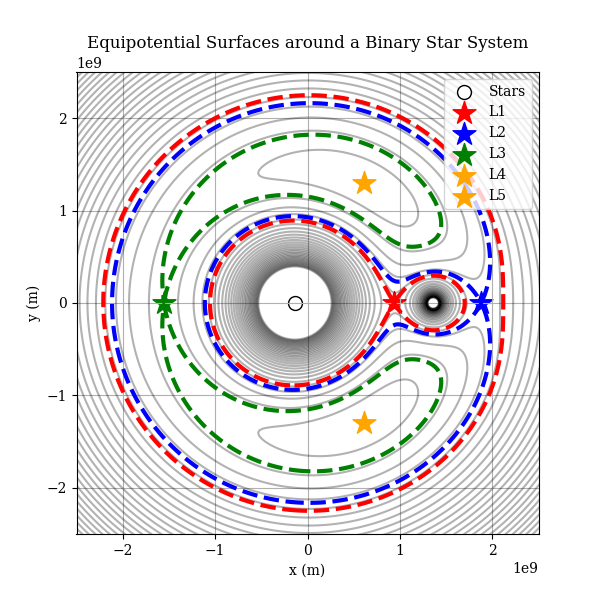

In [6]:
# Example usage
fig, ax = plt.subplots(figsize=(6,6))

m1 = 10*M_sun  # Mass of star 1 (in kg)
m2 = 1*M_sun  # Mass of star 2 (in kg)
a = 0.01*AU  # Separation between the stars (in meters)

# Plot the equipotential surfaces
plot_equipotential_surfaces(fig, ax, m1, m2, a, zoom=200, xcntr=0, num_contours=50)


### Fun fact: the shape of the potential is why we have tides on Earth!

#### Less fun fact: the Roche lobe is ill-defined if there is any eccentricity, which really complicates modelling of interactions in eccentric binaries. 

### ❓ Q: Where is the center of mass in this case? If the binary has unequal masses, the L1 point is much closer to the lower mass component. If this is the point where a particle at rest would feel no force toward either component, why is it not at the center of mass?

### The Roche lobe acts as an upper limit for how large a star can be. But as we saw on Wednesday, stars like to grow _a lot_. 

#### When a star tries to expand beyond its Roche lobe, its outer layers get stripped off, and funneled through the L1 Lagrange point. The matter then falls towards the companion. Some of it may be accreted onto the companion, increasing its mass. Some of it may form a disk of material around the companion. And some of it may be ejected out of the binary completely. 

<img src="data/images/accreting_binary.jpg" alt="Drawing" style="width: 600px;"/>

#### These different scenarios can change the final separation and period of the binaries after the interaction, and therefore the further evolution of the binary. In the modeling community, we are working hard to get constraints on these parameters, in order to better understand the final state of binary systems. 


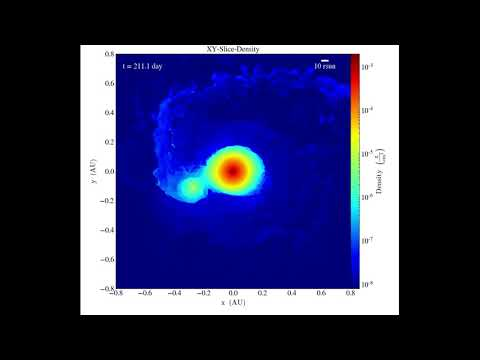

In [8]:
YouTubeVideo('dSDmtUfkfG8', width=800, height=400)

### If you remember from Wednesday, we learned that massive stars experience supernova explosions when they die. Supernova explosions involve a lot of sudden mass loss (from the envelope being explosively ejected) and also a birth kick from asymmetries in the explosion. 

### These two effects can change the orbit of the binary a lot. If the kick is very high, it can disrupt the orbit, meaning the two stars are no longer gravitationally bound. 

(Can't find a good image, just draw it on the blackboard)


### This is a _big problem_ if we want to form, for example, binary black holes. 

#### We’ve seen this earlier this week that the LIGO-Virgo-Kagra consortion has seen many mergers from binary black holes. But it takes a _really long time_ for two black holes in a binary to merge. In some cases, it can take longer than the entire age of the universe! 

#### The driving force for the binary to come together is still actually gravitational waves. But the energy radiated by gravitational waves is very weak at long distances, so it takes a long time for them to make a difference. 

#### The time required for a binary to merge depends on its separation once the binary black hole has formed (that is, the time of the second supernova). The bigger the kicks, the wider the binary when the binary black hole is formed, and the longer it will take for the two black holes to merge. 

<img src="data/images/inspiral_time.png" alt="Drawing" style="width: 600px;"/>
Description of the Peter's equations [Mandel (2021)]


### ! Back of the envelope problem: compute a scaling relation for T_c in years, for a in AU and M's in $M_\odot$

### Use: $c$ = 3e8 m/s, $G$(cgs) = 6.7e-8, 1 AU = 1.5e11 m, 1 $M_\odot$ = 1e33 g

### Assuming the above computation is done right, you should get an inspiral time of about 500 million years for a 10+10 $M_\odot$ circular binary starting at 1 AU separation. 

#### If you are agnostic about how binary black holes form, your challenge is to explain how two stellar-mass black holes can get within 1 AU of each other. 

#### From a stellar evolution perspective, you cannot have them form in isolation and be non-interacting. The space needed for both stars to expand to their full size is 2 orders of magnitude above 1 AU. So we must allow for binary interactions (mass transfer) and dynamical effects (supernova kicks) to bring the black holes together.


<img src="data/images/gw_inspiral.jpg" alt="Drawing" style="width: 600px;"/>

### ❓ Q: We expect that nearly all of this was new for you. What are some things you didn't understand about this session?